In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Load the data

In [3]:
from google.colab import files
uploaded = files.upload()

Saving bengaluru_house_prices.csv to bengaluru_house_prices.csv


In [4]:
df = pd.read_csv("bengaluru_house_prices.csv")
print(df.shape)
df.head()

(13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


## 2. Cleaning & feature engineering

In [7]:
data = df.drop(columns=['society', 'availability'])  # too sparse / low signal
data = data.dropna(subset=['location', 'size'])

# 'size' -> number of bedrooms (BHK)
data['bhk'] = data['size'].str.extract(r'(\d+)').astype(float)
data = data.drop(columns=['size'])

data[['bhk']].describe()

,bhk
count,13303.000000
mean,2.803728
std,1.295022
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,43.000000


In [8]:
def parse_sqft(x):
    x = str(x).strip()
    if '-' in x:
        parts = x.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    try:
        return float(x)
    except ValueError:
        return np.nan

data['total_sqft'] = data['total_sqft'].apply(parse_sqft)
data = data.dropna(subset=['total_sqft'])
data.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [9]:
data['bath'] = data['bath'].fillna(data['bath'].median())
data['balcony'] = data['balcony'].fillna(data['balcony'].median())

data['price_per_sqft'] = data['price'] * 100000 / data['total_sqft']

data.isnull().sum()

,0
area_type,0
location,0
total_sqft,0
bath,0
balcony,0
price,0
bhk,0
price_per_sqft,0


In [10]:

data = data[data['total_sqft'] / data['bhk'] >= 300]

low = data['price_per_sqft'].quantile(0.01)
high = data['price_per_sqft'].quantile(0.99)
data = data[(data['price_per_sqft'] >= low) & (data['price_per_sqft'] <= high)]

data = data.drop(columns=['price_per_sqft'])
print(data.shape)

(12261, 7)


In [11]:
data['location'] = data['location'].str.strip()
loc_counts = data['location'].value_counts()
rare_locations = loc_counts[loc_counts <= 10].index
data['location'] = data['location'].apply(lambda x: 'other' if x in rare_locations else x)

print("Unique locations after grouping:", data['location'].nunique())

Unique locations after grouping: 221


In [12]:
data = pd.get_dummies(data, columns=['area_type', 'location'], drop_first=True)
data.shape

(12261, 228)

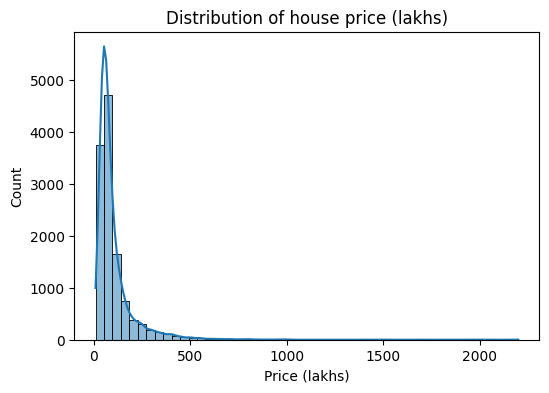

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(data['price'], bins=50, kde=True)
plt.title('Distribution of house price (lakhs)')
plt.xlabel('Price (lakhs)')
plt.show()

## 3. Train / test split & scaling

In [14]:
X = data.drop(columns=['price']).astype(float)
y = data['price'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (9808, 227)  Test shape: (2453, 227)


## 4. Build the FCNN regression model

In [15]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        29,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,553 (154.50 KB)

 Trainable params: 39,553 (154.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the model

In [16]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.6924 - mae: 0.4838 - val_loss: 0.3479 - val_mae: 0.3164
Epoch 2/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4303 - mae: 0.3677 - val_loss: 0.3181 - val_mae: 0.3023
Epoch 3/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3643 - mae: 0.3327 - val_loss: 0.3838 - val_mae: 0.2936
Epoch 4/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3552 - mae: 0.3236 - val_loss: 0.3314 - val_mae: 0.2705
Epoch 5/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2834 - mae: 0.3015 - val_loss: 0.3954 - val_mae: 0.2753
Epoch 6/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3191 - mae: 0.3001 - val_loss: 0.3434 - val_mae: 0.2756
Epoch 7/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2535 - mae: 0.2856 - val_loss: 0.3475 - val_mae: 0.2670
Epoch 8/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2571 - mae: 0.2793 - val_loss: 0.4249 - val_mae: 0.2588
Epoch 9/200
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms

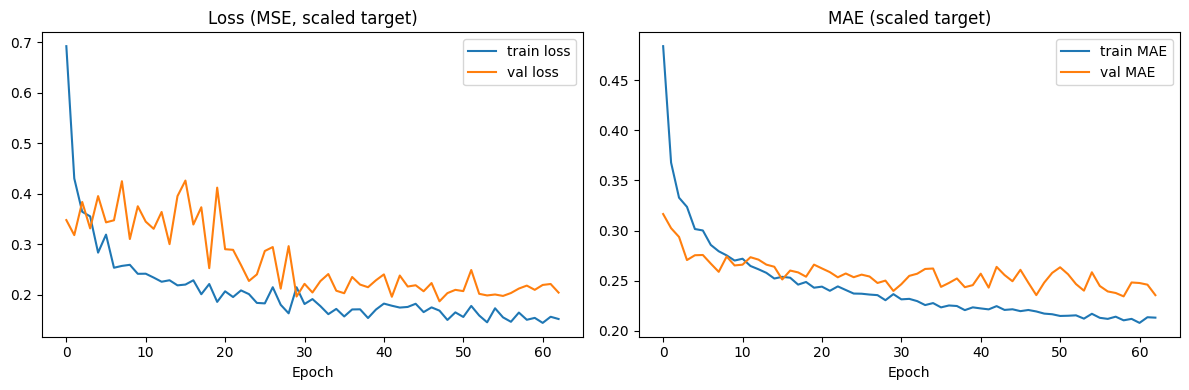

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(history.history['loss'], label='train loss')
ax[0].plot(history.history['val_loss'], label='val loss')
ax[0].set_title('Loss (MSE, scaled target)'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(history.history['mae'], label='train MAE')
ax[1].plot(history.history['val_mae'], label='val MAE')
ax[1].set_title('MAE (scaled target)'); ax[1].set_xlabel('Epoch'); ax[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluate on the test set

In [18]:
y_pred_scaled = model.predict(X_test_scaled).ravel()

y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f} lakhs")
print(f"RMSE : {rmse:.2f} lakhs")
print(f"R2   : {r2:.4f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE  : 30.02 lakhs
RMSE : 69.50 lakhs
R2   : 0.6636


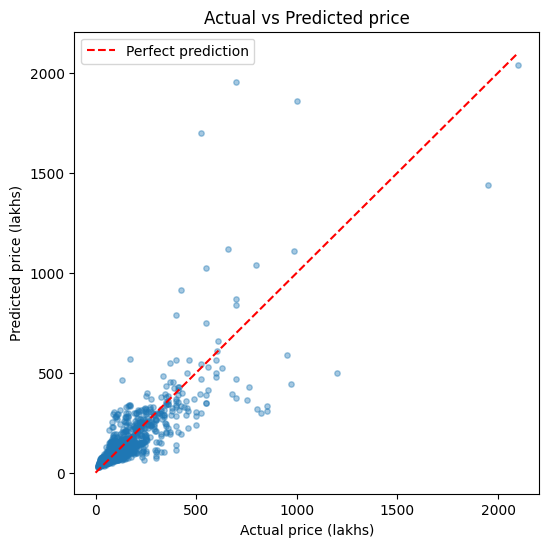

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, s=15)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual price (lakhs)')
plt.ylabel('Predicted price (lakhs)')
plt.title('Actual vs Predicted price')
plt.legend()
plt.show()

## 7. Save the model

In [20]:
model.save('bengaluru_house_price_fcnn_model.keras')
print("Model saved as bengaluru_house_price_fcnn_model.keras")

Model saved as bengaluru_house_price_fcnn_model.keras
